# Criblage virtuel de molécules bioactives avec ChEMBL et CUDA

**Objectif.** Construire un modèle de classification capable de prioriser des molécules
susceptibles d'inhiber l'EGFR humain (`CHEMBL203`) à partir des mesures `IC50` de ChEMBL.

Le pipeline évite deux pièges fréquents en cheminformatique :

- les mesures ambiguës sont écartées (actif si pChEMBL ≥ 6.5, inactif si ≤ 5.5) ;
- la séparation est faite par scaffold de Bemis–Murcko, et non aléatoirement, afin de
  mesurer la généralisation à de nouvelles familles chimiques.

Le modèle est un MLP PyTorch sur fingerprints Morgan. La génération des fingerprints
reste sur CPU (RDKit) ; l'entraînement et l'inférence par lots utilisent la RTX 4060.
Le dernier bloc exporte TorchScript, `state_dict`, ONNX et les métadonnées nécessaires
pour reproduire exactement le prétraitement.

In [1]:
from __future__ import annotations

import json
import math
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold
from requests.adapters import HTTPAdapter
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from urllib3.util.retry import Retry

# La standardisation émet sinon plusieurs lignes par molécule dans un notebook exécuté.
RDLogger.DisableLog("rdApp.*")
sns.set_theme(style="whitegrid", context="notebook")


@dataclass(frozen=True)
class Config:
    seed: int = 42
    target_chembl_id: str = "CHEMBL203"  # EGFR humain
    target_name: str = "Epidermal growth factor receptor (EGFR)"
    active_threshold: float = 6.5
    inactive_threshold: float = 5.5
    fp_radius: int = 2
    fp_size: int = 2048
    train_fraction: float = 0.80
    valid_fraction: float = 0.10
    test_fraction: float = 0.10
    batch_size: int = 256
    epochs: int = 60
    patience: int = 10
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    dropout: float = 0.30
    min_heavy_atoms: int = 8
    max_heavy_atoms: int = 80
    # Mettre un entier (par exemple 3000) pour un essai rapide.
    max_records: int | None = None


CFG = Config()
ROOT = Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
ARTIFACT_DIR = ROOT / "artifacts"
for directory in (RAW_DIR, PROCESSED_DIR, ARTIFACT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG.seed)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Device         : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"CUDA PyTorch   : {torch.version.cuda}")
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"VRAM libre     : {free_b / 2**30:.2f} / {total_b / 2**30:.2f} Gio")
else:
    print("ATTENTION : entraînement CPU. Vérifier l'installation PyTorch CUDA.")

PyTorch        : 2.11.0+cu128
CUDA disponible: True
Device         : cuda
GPU            : NVIDIA GeForce RTX 4060 Laptop GPU
CUDA PyTorch   : 12.8
VRAM libre     : 6.94 / 8.00 Gio


## 1. Téléchargement reproductible depuis ChEMBL

L'API officielle est interrogée par pages. Seules les activités de liaison (`assay_type=B`)
humaines, de type `IC50`, disposant d'une valeur pChEMBL et d'un SMILES sont conservées.
La réponse brute est mise en cache localement.

In [2]:
def requests_session() -> requests.Session:
    retry = Retry(
        total=5,
        backoff_factor=1.0,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=("GET",),
    )
    session = requests.Session()
    session.headers.update({"User-Agent": "chembl-virtual-screening-notebook/1.0"})
    session.mount("https://", HTTPAdapter(max_retries=retry))
    return session


def chembl_status(session: requests.Session) -> dict:
    response = session.get("https://www.ebi.ac.uk/chembl/api/data/status.json", timeout=60)
    response.raise_for_status()
    return response.json()


def download_chembl_activities(config: Config, force: bool = False) -> tuple[pd.DataFrame, dict]:
    cache_path = RAW_DIR / f"{config.target_chembl_id}_IC50_activities.csv.gz"
    metadata_path = RAW_DIR / f"{config.target_chembl_id}_download_metadata.json"
    if cache_path.exists() and metadata_path.exists() and not force:
        return pd.read_csv(cache_path), json.loads(metadata_path.read_text(encoding="utf-8"))

    session = requests_session()
    status = chembl_status(session)
    url = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
    params = {
        "target_chembl_id": config.target_chembl_id,
        "target_organism": "Homo sapiens",
        "assay_type": "B",
        "standard_type": "IC50",
        "pchembl_value__isnull": "false",
        "canonical_smiles__isnull": "false",
        "limit": 1000,
        "only": ",".join(
            [
                "activity_id",
                "molecule_chembl_id",
                "parent_molecule_chembl_id",
                "canonical_smiles",
                "pchembl_value",
                "standard_relation",
                "standard_value",
                "standard_units",
                "assay_chembl_id",
                "document_chembl_id",
                "data_validity_comment",
            ]
        ),
    }

    records: list[dict] = []
    next_url: str | None = url
    first_request = True
    progress = tqdm(desc="Activités ChEMBL", unit=" activité")
    while next_url:
        response = session.get(next_url, params=params if first_request else None, timeout=120)
        response.raise_for_status()
        payload = response.json()
        batch = payload.get("activities", [])
        records.extend(batch)
        progress.update(len(batch))
        if config.max_records is not None and len(records) >= config.max_records:
            records = records[: config.max_records]
            break
        next_url = payload.get("page_meta", {}).get("next")
        if next_url and next_url.startswith("/"):
            next_url = "https://www.ebi.ac.uk" + next_url
        first_request = False
    progress.close()

    frame = pd.DataFrame(records)
    metadata = {
        "downloaded_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
        "chembl_status": status,
        "query": params,
        "raw_record_count": len(frame),
    }
    frame.to_csv(cache_path, index=False, compression="gzip")
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return frame, metadata


raw_df, download_metadata = download_chembl_activities(CFG)
print("Version ChEMBL :", download_metadata.get("chembl_status", {}).get("chembl_db_version", "inconnue"))
print(f"Activités brutes: {len(raw_df):,}")
display(raw_df.head(3))

Version ChEMBL : ChEMBL_37
Activités brutes: 18,106


,activity_id,assay_chembl_id,canonical_smiles,data_validity_comment,document_chembl_id,molecule_chembl_id,parent_molecule_chembl_id,pchembl_value,relation,standard_relation,standard_units,standard_value,units,value
0,32260,CHEMBL674637,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,NaN,CHEMBL1134862,CHEMBL68920,CHEMBL68920,7.39,=,=,nM,41.0,uM,0.041
1,32267,CHEMBL674637,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,NaN,CHEMBL1134862,CHEMBL69960,CHEMBL69960,6.77,=,=,nM,170.0,uM,0.170
2,32680,CHEMBL677833,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,NaN,CHEMBL1145114,CHEMBL137635,CHEMBL137635,5.03,=,=,nM,9300.0,uM,9.300


## 2. Standardisation, agrégation et création des labels

Les sels sont ramenés à leur fragment parent, les charges sont neutralisées lorsque possible,
puis les mesures répétées d'une même structure sont agrégées par la médiane. L'espace entre
5.5 et 6.5 constitue une zone grise exclue de l'apprentissage.

Standardisation RDKit:   0%|          | 0/18106 [00:00<?, ?it/s]

Molécules uniques retenues: 8,325


,classe,effectif
0,inactive (0),1685
1,active (1),6640


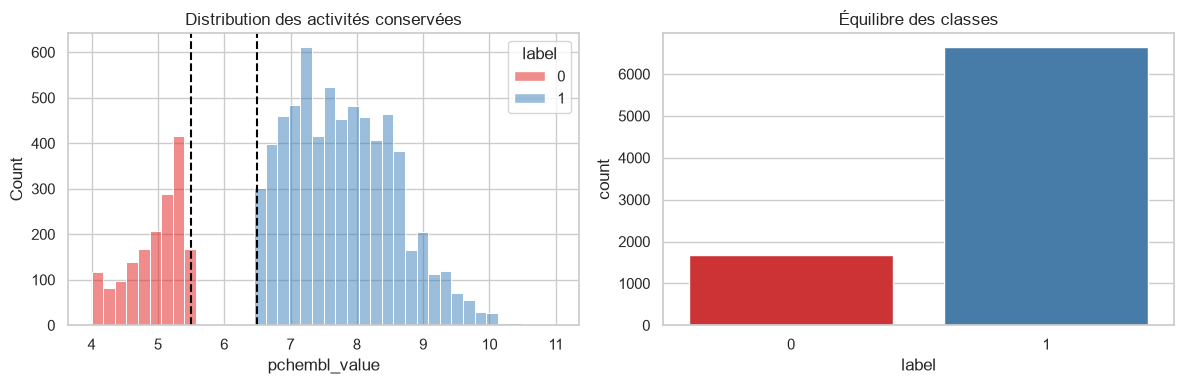

In [3]:
uncharger = rdMolStandardize.Uncharger()


def standardize_smiles(smiles: str) -> tuple[str | None, int | None, float | None]:
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None, None, None
        mol = rdMolStandardize.Cleanup(mol)
        mol = rdMolStandardize.FragmentParent(mol)
        mol = uncharger.uncharge(mol)
        Chem.SanitizeMol(mol)
        canonical = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
        return canonical, mol.GetNumHeavyAtoms(), Descriptors.MolWt(mol)
    except Exception:
        return None, None, None


def curate_activities(raw: pd.DataFrame, config: Config) -> pd.DataFrame:
    frame = raw.copy()
    frame["pchembl_value"] = pd.to_numeric(frame["pchembl_value"], errors="coerce")
    frame = frame.dropna(subset=["canonical_smiles", "pchembl_value"])
    if "standard_relation" in frame:
        relation = frame["standard_relation"].fillna("").astype(str).str.strip()
        frame = frame[relation.isin(["=", ""])].copy()
    if "data_validity_comment" in frame:
        invalid = frame["data_validity_comment"].fillna("").astype(str).str.lower()
        frame = frame[~invalid.str.contains("invalid|outside typical range", regex=True)].copy()

    standardized = [standardize_smiles(s) for s in tqdm(frame["canonical_smiles"], desc="Standardisation RDKit")]
    frame[["smiles", "heavy_atoms", "mol_wt"]] = pd.DataFrame(standardized, index=frame.index)
    frame = frame.dropna(subset=["smiles"])
    frame = frame[frame["heavy_atoms"].between(config.min_heavy_atoms, config.max_heavy_atoms)]

    curated = (
        frame.groupby("smiles", as_index=False)
        .agg(
            pchembl_value=("pchembl_value", "median"),
            pchembl_std=("pchembl_value", "std"),
            measurement_count=("pchembl_value", "size"),
            molecule_chembl_id=("molecule_chembl_id", "first"),
            heavy_atoms=("heavy_atoms", "first"),
            mol_wt=("mol_wt", "first"),
        )
    )
    curated["label"] = np.where(
        curated["pchembl_value"] >= config.active_threshold,
        1,
        np.where(curated["pchembl_value"] <= config.inactive_threshold, 0, -1),
    )
    curated = curated[curated["label"] >= 0].copy()
    curated["label"] = curated["label"].astype(np.int8)
    curated["scaffold"] = curated["smiles"].map(
        lambda s: MurckoScaffold.MurckoScaffoldSmiles(smiles=s, includeChirality=False)
    )
    # Les structures acycliques ont un scaffold vide : on les empêche de former un groupe géant.
    empty = curated["scaffold"].eq("")
    curated.loc[empty, "scaffold"] = "ACYCLIC_" + curated.loc[empty, "smiles"]
    return curated.reset_index(drop=True)


df = curate_activities(raw_df, CFG)
df.to_csv(PROCESSED_DIR / f"{CFG.target_chembl_id}_curated.csv.gz", index=False, compression="gzip")
summary = pd.DataFrame(
    {
        "classe": ["inactive (0)", "active (1)"],
        "effectif": [(df.label == 0).sum(), (df.label == 1).sum()],
    }
)
print(f"Molécules uniques retenues: {len(df):,}")
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="pchembl_value", hue="label", bins=40, ax=axes[0], palette="Set1")
axes[0].axvline(CFG.inactive_threshold, color="black", ls="--")
axes[0].axvline(CFG.active_threshold, color="black", ls="--")
axes[0].set_title("Distribution des activités conservées")
sns.countplot(data=df, x="label", ax=axes[1], hue="label", legend=False, palette="Set1")
axes[1].set_title("Équilibre des classes")
plt.tight_layout()
plt.show()

## 3. Fingerprints Morgan et split par scaffold

In [4]:
MORGAN = AllChem.GetMorganGenerator(radius=CFG.fp_radius, fpSize=CFG.fp_size)


def smiles_to_fp(smiles: str) -> np.ndarray:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"SMILES invalide: {smiles}")
    fp = MORGAN.GetFingerprint(mol)
    array = np.zeros((CFG.fp_size,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, array)
    return array


X = np.vstack([smiles_to_fp(s) for s in tqdm(df.smiles, desc="Fingerprints Morgan")])
y = df.label.to_numpy(dtype=np.float32)
print("Matrice X:", X.shape, "— mémoire:", f"{X.nbytes / 2**20:.1f} Mio")


def scaffold_split(frame: pd.DataFrame, config: Config) -> dict[str, np.ndarray]:
    groups = [group.index.to_numpy() for _, group in frame.groupby("scaffold")]
    rng = np.random.default_rng(config.seed)
    rng.shuffle(groups)
    groups.sort(key=len, reverse=True)

    target_sizes = np.array(
        [config.train_fraction, config.valid_fraction, config.test_fraction]
    ) * len(frame)
    splits: list[list[int]] = [[], [], []]
    for group in groups:
        remaining = target_sizes - np.array([len(split) for split in splits])
        destination = int(np.argmax(remaining))
        splits[destination].extend(group.tolist())

    result = {
        "train": np.asarray(splits[0], dtype=int),
        "valid": np.asarray(splits[1], dtype=int),
        "test": np.asarray(splits[2], dtype=int),
    }
    # Contrôles anti-fuite.
    scaffold_sets = {name: set(frame.loc[idx, "scaffold"]) for name, idx in result.items()}
    assert scaffold_sets["train"].isdisjoint(scaffold_sets["valid"])
    assert scaffold_sets["train"].isdisjoint(scaffold_sets["test"])
    assert scaffold_sets["valid"].isdisjoint(scaffold_sets["test"])
    assert sum(map(len, result.values())) == len(frame)
    return result


split_idx = scaffold_split(df, CFG)
split_rows = []
for name, idx in split_idx.items():
    split_rows.append(
        {
            "split": name,
            "n": len(idx),
            "actifs": int(y[idx].sum()),
            "% actifs": float(100 * y[idx].mean()),
            "scaffolds": int(df.loc[idx, "scaffold"].nunique()),
        }
    )
    df.loc[idx, "split"] = name
display(pd.DataFrame(split_rows).round(2))
df.to_csv(PROCESSED_DIR / f"{CFG.target_chembl_id}_curated_with_split.csv.gz", index=False, compression="gzip")

Fingerprints Morgan:   0%|          | 0/8325 [00:00<?, ?it/s]

Matrice X: (8325, 2048) — mémoire: 65.0 Mio


,split,n,actifs,% actifs,scaffolds
0,train,6660,5355,80.41,1546
1,valid,833,643,77.19,749
2,test,832,642,77.16,748


## 4. Modèle PyTorch et entraînement CUDA

BioactivityMLP(
  (network): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=64, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.15, inplace=False)
    (11): Linear(in_features=64, out_features=1, bias=True)
  )
)
Paramètres entraînables: 1,198,465
Poids de la classe active: 0.244


Epoch 01 | loss=0.1479 | val ROC-AUC=0.9212 | val PR-AUC=0.9744
Epoch 02 | loss=0.0662 | val ROC-AUC=0.9223 | val PR-AUC=0.9745


Epoch 03 | loss=0.0407 | val ROC-AUC=0.9204 | val PR-AUC=0.9735
Epoch 04 | loss=0.0312 | val ROC-AUC=0.9187 | val PR-AUC=0.9713


Epoch 05 | loss=0.0280 | val ROC-AUC=0.9199 | val PR-AUC=0.9738
Epoch 06 | loss=0.0212 | val ROC-AUC=0.9179 | val PR-AUC=0.9723


Epoch 07 | loss=0.0162 | val ROC-AUC=0.9195 | val PR-AUC=0.9712
Epoch 08 | loss=0.0127 | val ROC-AUC=0.9135 | val PR-AUC=0.9699


Epoch 09 | loss=0.0102 | val ROC-AUC=0.9132 | val PR-AUC=0.9697
Epoch 10 | loss=0.0088 | val ROC-AUC=0.9117 | val PR-AUC=0.9682


Epoch 11 | loss=0.0065 | val ROC-AUC=0.9142 | val PR-AUC=0.9684
Epoch 12 | loss=0.0056 | val ROC-AUC=0.9162 | val PR-AUC=0.9695
Early stopping après 12 époques.


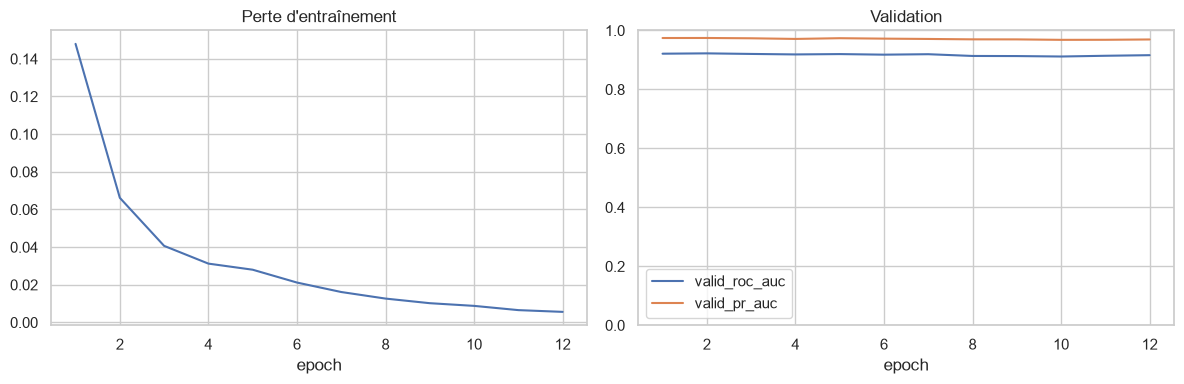

In [5]:
def make_loader(indices: np.ndarray, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.from_numpy(X[indices]), torch.from_numpy(y[indices]))
    generator = torch.Generator().manual_seed(CFG.seed)
    return DataLoader(
        dataset,
        batch_size=CFG.batch_size,
        shuffle=shuffle,
        num_workers=0,  # robuste sous Windows/Jupyter
        pin_memory=DEVICE.type == "cuda",
        generator=generator if shuffle else None,
    )


train_loader = make_loader(split_idx["train"], shuffle=True)
valid_loader = make_loader(split_idx["valid"], shuffle=False)
test_loader = make_loader(split_idx["test"], shuffle=False)


class BioactivityMLP(nn.Module):
    def __init__(self, input_dim: int = 2048, dropout: float = 0.30):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)


model = BioactivityMLP(CFG.fp_size, CFG.dropout).to(DEVICE)
n_pos = float(y[split_idx["train"]].sum())
n_neg = float(len(split_idx["train"]) - n_pos)
pos_weight = torch.tensor([n_neg / max(n_pos, 1.0)], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
print(model)
print(f"Paramètres entraînables: {sum(p.numel() for p in model.parameters()):,}")
print(f"Poids de la classe active: {pos_weight.item():.3f}")


@torch.inference_mode()
def predict_loader(net: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    net.eval()
    probabilities, labels = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = net(xb)
        probabilities.append(torch.sigmoid(logits).cpu().numpy())
        labels.append(yb.numpy())
    return np.concatenate(labels), np.concatenate(probabilities)


def safe_auc(labels: np.ndarray, scores: np.ndarray, metric) -> float:
    return float(metric(labels, scores)) if np.unique(labels).size == 2 else float("nan")


history: list[dict] = []
best_auc = -math.inf
best_state = None
epochs_without_improvement = 0

for epoch in range(1, CFG.epochs + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=DEVICE.type == "cuda"):
            logits = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * len(xb)

    val_y, val_prob = predict_loader(model, valid_loader)
    val_auc = safe_auc(val_y, val_prob, roc_auc_score)
    val_ap = safe_auc(val_y, val_prob, average_precision_score)
    train_loss = running_loss / len(train_loader.dataset)
    scheduler.step(val_auc)
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_roc_auc": val_auc,
            "valid_pr_auc": val_ap,
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
    )
    print(
        f"Epoch {epoch:02d} | loss={train_loss:.4f} | "
        f"val ROC-AUC={val_auc:.4f} | val PR-AUC={val_ap:.4f}"
    )
    if val_auc > best_auc + 1e-4:
        best_auc = val_auc
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= CFG.patience:
            print(f"Early stopping après {epoch} époques.")
            break

assert best_state is not None
model.load_state_dict(best_state)
model.to(DEVICE)
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df.plot(x="epoch", y="train_loss", ax=axes[0], legend=False, title="Perte d'entraînement")
history_df.plot(x="epoch", y=["valid_roc_auc", "valid_pr_auc"], ax=axes[1], title="Validation")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Choix du seuil sur validation et évaluation finale

Le jeu de test reste intact jusqu'à cette étape. Le seuil de décision maximise le MCC sur
la validation, métrique adaptée aux classes potentiellement déséquilibrées.

,test
roc_auc,0.9200
pr_auc,0.9732
mcc,0.5819
balanced_accuracy,0.7593
decision_threshold,0.1400
n_test,832.0000


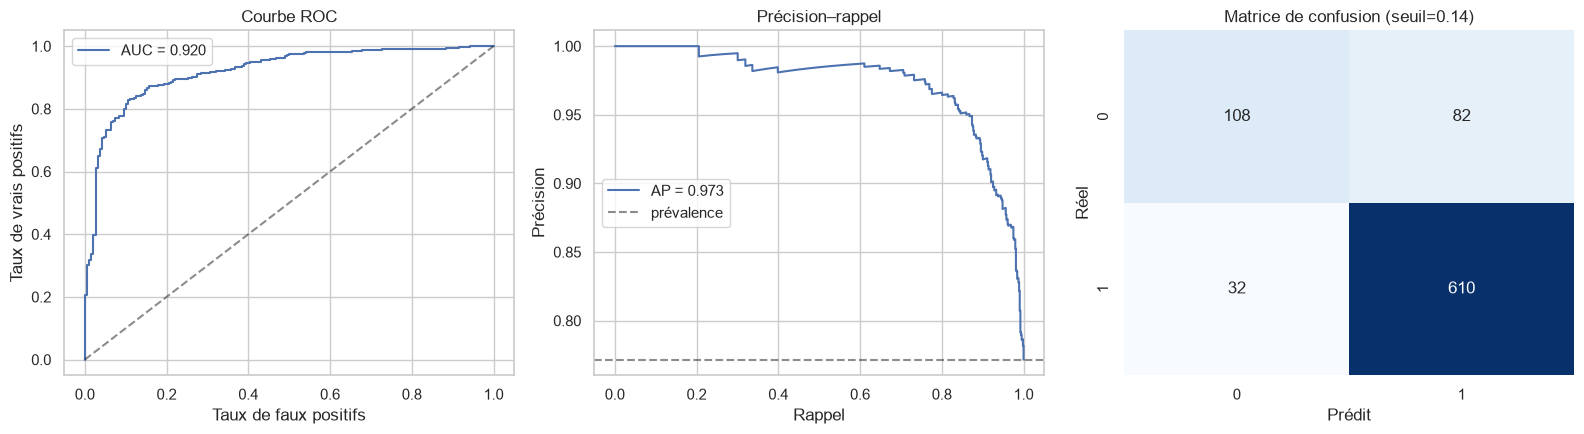

In [6]:
val_y, val_prob = predict_loader(model, valid_loader)
threshold_grid = np.linspace(0.05, 0.95, 181)
validation_mcc = np.array(
    [matthews_corrcoef(val_y, val_prob >= threshold) for threshold in threshold_grid]
)
best_threshold = float(threshold_grid[np.argmax(validation_mcc)])

test_y, test_prob = predict_loader(model, test_loader)
test_pred = (test_prob >= best_threshold).astype(int)
metrics = {
    "roc_auc": safe_auc(test_y, test_prob, roc_auc_score),
    "pr_auc": safe_auc(test_y, test_prob, average_precision_score),
    "mcc": float(matthews_corrcoef(test_y, test_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(test_y, test_pred)),
    "decision_threshold": best_threshold,
    "n_test": int(len(test_y)),
}
display(pd.Series(metrics, name="test").to_frame().round(4))

fpr, tpr, _ = roc_curve(test_y, test_prob)
precision, recall, _ = precision_recall_curve(test_y, test_prob)
cm = confusion_matrix(test_y, test_pred)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set(xlabel="Taux de faux positifs", ylabel="Taux de vrais positifs", title="Courbe ROC")
axes[0].legend()
axes[1].plot(recall, precision, label=f"AP = {metrics['pr_auc']:.3f}")
axes[1].axhline(test_y.mean(), color="k", ls="--", alpha=0.5, label="prévalence")
axes[1].set(xlabel="Rappel", ylabel="Précision", title="Précision–rappel")
axes[1].legend()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set(xlabel="Prédit", ylabel="Réel", title=f"Matrice de confusion (seuil={best_threshold:.2f})")
plt.tight_layout()
figure_path = ARTIFACT_DIR / "evaluation.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

test_predictions = df.loc[split_idx["test"], ["molecule_chembl_id", "smiles", "pchembl_value", "label"]].copy()
test_predictions["probability_active"] = test_prob
test_predictions["prediction"] = test_pred
test_predictions.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)

## 6. Export du modèle

- `bioactivity_mlp_scripted.pt` : format autonome recommandé pour l'inférence PyTorch ;
- `bioactivity_mlp_state_dict.pt` : poids + architecture/configuration pour réentraînement ;
- `bioactivity_mlp.onnx` : format interopérable ;
- `model_metadata.json` : seuil, fingerprint, cible, version ChEMBL et métriques.

In [7]:
model_cpu = BioactivityMLP(CFG.fp_size, CFG.dropout)
model_cpu.load_state_dict(best_state)
model_cpu.eval()

scripted_path = ARTIFACT_DIR / "bioactivity_mlp_scripted.pt"
state_path = ARTIFACT_DIR / "bioactivity_mlp_state_dict.pt"
onnx_path = ARTIFACT_DIR / "bioactivity_mlp.onnx"
metadata_path = ARTIFACT_DIR / "model_metadata.json"

dummy = torch.zeros(1, CFG.fp_size, dtype=torch.float32)
# Le traçage est plus robuste qu'un script dans les cellules Jupyter sous Windows.
scripted = torch.jit.trace(model_cpu, dummy)
scripted.save(str(scripted_path))
torch.save(
    {
        "model_state_dict": best_state,
        "model_class": "BioactivityMLP",
        "input_dim": CFG.fp_size,
        "dropout": CFG.dropout,
        "config": asdict(CFG),
    },
    state_path,
)

torch.onnx.export(
    model_cpu,
    dummy,
    str(onnx_path),
    input_names=["morgan_fp"],
    output_names=["logit"],
    dynamic_axes={"morgan_fp": {0: "batch"}, "logit": {0: "batch"}},
    opset_version=18,
    dynamo=False,
)

metadata = {
    "project": "Virtual screening de molécules bioactives",
    "target": {"chembl_id": CFG.target_chembl_id, "name": CFG.target_name},
    "task": "binary classification",
    "label_definition": {
        "active": f"pChEMBL >= {CFG.active_threshold}",
        "inactive": f"pChEMBL <= {CFG.inactive_threshold}",
        "gray_zone": "excluded",
    },
    "input": {
        "type": "Morgan bit fingerprint",
        "radius": CFG.fp_radius,
        "n_bits": CFG.fp_size,
        "standardization": "RDKit Cleanup + FragmentParent + Uncharger",
    },
    "split": "Bemis-Murcko scaffold split 80/10/10",
    "decision_threshold": best_threshold,
    "metrics_test": metrics,
    "dataset": {
        "n_curated": len(df),
        "n_train": len(split_idx["train"]),
        "n_valid": len(split_idx["valid"]),
        "n_test": len(split_idx["test"]),
        "chembl_db_version": download_metadata.get("chembl_status", {}).get("chembl_db_version"),
        "downloaded_at_utc": download_metadata.get("downloaded_at_utc"),
    },
    "runtime": {"torch": torch.__version__, "rdkit": Chem.rdBase.rdkitVersion},
    "limitations": [
        "Priorisation in silico uniquement; validation expérimentale requise.",
        "Les scores hors du domaine chimique du train sont moins fiables.",
        "Le split scaffold réduit mais n'élimine pas toutes les formes de fuite de données.",
    ],
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Artefacts exportés :")
for path in [scripted_path, state_path, onnx_path, metadata_path, figure_path]:
    print(f"- {path} ({path.stat().st_size / 2**20:.2f} Mio)")

Artefacts exportés :
- D:\Study\MLOPS\artifacts\bioactivity_mlp_scripted.pt (4.61 Mio)
- D:\Study\MLOPS\artifacts\bioactivity_mlp_state_dict.pt (4.58 Mio)
- D:\Study\MLOPS\artifacts\bioactivity_mlp.onnx (4.58 Mio)
- D:\Study\MLOPS\artifacts\model_metadata.json (0.00 Mio)
- D:\Study\MLOPS\artifacts\evaluation.png (0.09 Mio)


C:\Users\med31\AppData\Local\Temp\ipykernel_14608\488827298.py:25: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


## 7. Scorer de nouvelles molécules et estimer le domaine d'applicabilité

La similarité Tanimoto maximale avec le train sert d'indicateur simple de domaine. Un score
prédictif élevé avec une similarité faible doit être interprété avec prudence.

In [8]:
train_bitvectors = []
for row in X[split_idx["train"]].astype(np.uint8):
    bitvector = DataStructs.ExplicitBitVect(CFG.fp_size)
    for bit in np.flatnonzero(row):
        bitvector.SetBit(int(bit))
    train_bitvectors.append(bitvector)


def score_smiles(smiles_list: Iterable[str], applicability_cutoff: float = 0.30) -> pd.DataFrame:
    loaded_model = torch.jit.load(str(scripted_path), map_location="cpu").eval()
    rows = []
    for original in smiles_list:
        standardized, _, _ = standardize_smiles(original)
        if standardized is None:
            rows.append({"smiles": original, "error": "SMILES invalide"})
            continue
        mol = Chem.MolFromSmiles(standardized)
        query_bv = MORGAN.GetFingerprint(mol)
        similarities = DataStructs.BulkTanimotoSimilarity(query_bv, train_bitvectors)
        max_similarity = float(max(similarities)) if similarities else float("nan")
        fp = torch.from_numpy(smiles_to_fp(standardized)).unsqueeze(0)
        with torch.inference_mode():
            probability = float(torch.sigmoid(loaded_model(fp)).item())
        rows.append(
            {
                "smiles": original,
                "standardized_smiles": standardized,
                "probability_active": probability,
                "prediction": "active" if probability >= best_threshold else "inactive",
                "max_train_tanimoto": max_similarity,
                "in_applicability_domain": max_similarity >= applicability_cutoff,
            }
        )
    return pd.DataFrame(rows)


example_smiles = {
    "gefitinib": "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1",
    "erlotinib": "COCCOc1cc2ncnc(Nc3cccc(C#C)c3)c2cc1OCCOC",
    "caffeine": "Cn1c(=O)c2c(ncn2C)n(C)c1=O",
}
example_scores = score_smiles(example_smiles.values())
example_scores.insert(0, "name", example_smiles.keys())
display(example_scores.round(4))

,name,smiles,standardized_smiles,probability_active,prediction,max_train_tanimoto,in_applicability_domain
0,gefitinib,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,0.9739,active,1.0000,True
1,erlotinib,COCCOc1cc2ncnc(Nc3cccc(C#C)c3)c2cc1OCCOC,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,0.9967,active,1.0000,True
2,caffeine,Cn1c(=O)c2c(ncn2C)n(C)c1=O,Cn1c(=O)c2c(ncn2C)n(C)c1=O,0.0719,inactive,0.2308,False


## Conclusion

Le modèle exporté produit une **probabilité de bioactivité EGFR** à partir d'un SMILES.
Pour un vrai écran virtuel, chargez une bibliothèque de SMILES, standardisez-la avec la même
fonction, scorez par lots, puis priorisez les composés combinant probabilité élevée, présence
dans le domaine d'applicabilité, diversité de scaffolds et propriétés physicochimiques adaptées.